# State of Data 2023–2025: análise da camada Gold

**Tech Challenge — Data Analytics | FIAP**

Este é um notebook analítico independente, cujo ponto de partida são exclusivamente os 12 arquivos CSV exportados das tabelas Gold no Amazon Athena.

Ele não executa nem depende dos tratamentos das camadas Bronze e Silver. Seu objetivo é transformar os dados Gold já estruturados em evidências sobre competências, carreira, remuneração, satisfação, diversidade e modelos de trabalho no mercado brasileiro de Dados.

## 1. Instalação das bibliotecas

A primeira célula concentra as dependências utilizadas. No Google Colab, execute-a uma vez antes das demais.

In [2]:
# Instala as bibliotecas utilizadas na análise e nos gráficos
%pip -q install "pandas>=2.0,<3.0" "matplotlib>=3.7,<4.0" "seaborn>=0.13,<0.14"

## 2. Configuração do ambiente

O código funciona tanto no Google Colab quanto em um repositório local. No Colab, ele procura primeiro os arquivos dentro do Google Drive e depois em `/content`.

In [3]:
# Importa bibliotecas de manipulação de dados, caminhos e visualização
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# Reduz mensagens que não alteram os resultados da análise
warnings.filterwarnings("ignore")

# Identifica se o notebook está sendo executado no Google Colab
try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

# Monta o Google Drive quando o notebook estiver no Colab
if EM_COLAB:
    drive.mount("/content/drive")

# Define os possíveis locais dos CSVs exportados do Athena
caminhos_candidatos = [
    Path("/content/drive/MyDrive/Tech_Challenge_Fase_3/data/athena_results"),
    Path("/content/drive/MyDrive/Tech_Challenge_Fase_3/data/gold"),
    Path("/content"),
    Path.cwd() / "data" / "gold",
    Path.cwd(),
]

# Localiza automaticamente a pasta que contém os arquivos Gold
arquivo_referencia = "fiap_state_of_data.gold_mercado.csv"
DATA_DIR = next(
    (pasta for pasta in caminhos_candidatos if (pasta / arquivo_referencia).exists()),
    None,
)

# Interrompe a execução com uma orientação clara caso os arquivos não sejam encontrados
if DATA_DIR is None:
    raise FileNotFoundError(
        "Os CSVs Gold não foram encontrados. Coloque os arquivos em "
        "Tech_Challenge_Fase_3/data/athena_results no Google Drive, "
        "em data/gold no repositório ou diretamente em /content."
    )

# Define a pasta de saída dos gráficos
if EM_COLAB:
    OUTPUT_DIR = Path("/content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold")
else:
    OUTPUT_DIR = Path.cwd() / "outputs" / "graficos_gold"

# Cria a pasta de saída quando necessário
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Exibe os caminhos efetivamente utilizados
print("Pasta dos dados:", DATA_DIR)
print("Pasta dos gráficos:", OUTPUT_DIR)

Mounted at /content/drive
Pasta dos dados: /content
Pasta dos gráficos: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold


## 3. Leitura das 12 tabelas Gold

Cada arquivo mantém o nome da tabela de origem no Glue Data Catalog e no Athena.

In [4]:
# Relaciona o nome lógico de cada dataset ao respectivo arquivo exportado do Athena
arquivos_gold = {
    "diversidade": "fiap_state_of_data.gold_diversidade.csv",
    "experiencia": "fiap_state_of_data.gold_experiencia.csv",
    "formacao": "fiap_state_of_data.gold_formacao.csv",
    "geografia": "fiap_state_of_data.gold_geografia.csv",
    "ia": "fiap_state_of_data.gold_ia.csv",
    "indicadores_anuais": "fiap_state_of_data.gold_indicadores_anuais.csv",
    "mercado": "fiap_state_of_data.gold_mercado.csv",
    "modelo_trabalho": "fiap_state_of_data.gold_modelo_trabalho.csv",
    "remuneracao": "fiap_state_of_data.gold_remuneracao.csv",
    "satisfacao": "fiap_state_of_data.gold_satisfacao.csv",
    "setores": "fiap_state_of_data.gold_setores.csv",
    "tecnologias": "fiap_state_of_data.gold_tecnologias.csv",
}

# Carrega todos os arquivos em um dicionário de DataFrames pandas
gold = {
    nome: pd.read_csv(DATA_DIR / arquivo)
    for nome, arquivo in arquivos_gold.items()
}

# Cria atalhos para as tabelas mais utilizadas nas análises
df_indicadores = gold["indicadores_anuais"].copy()
df_mercado = gold["mercado"].copy()
df_tecnologias = gold["tecnologias"].copy()
df_ia = gold["ia"].copy()
df_remuneracao = gold["remuneracao"].copy()
df_satisfacao = gold["satisfacao"].copy()
df_modelo_trabalho = gold["modelo_trabalho"].copy()
df_diversidade = gold["diversidade"].copy()

# Exibe as dimensões das tabelas carregadas
resumo_carga = pd.DataFrame([
    {"tabela": nome, "linhas": len(df), "colunas": len(df.columns)}
    for nome, df in gold.items()
]).sort_values("tabela")

display(resumo_carga)

,tabela,linhas,colunas
0,diversidade,14002,12
1,experiencia,14002,15
2,formacao,14002,14
3,geografia,14002,11
4,ia,14002,13
5,indicadores_anuais,3,14
6,mercado,14002,12
7,modelo_trabalho,14002,13
8,remuneracao,12840,16
9,satisfacao,14002,12


## 4. Qualidade e reconciliação dos dados

Os testes abaixo verificam volumes, duplicidades, anos disponíveis e colunas necessárias. Valores ausentes em cargo, salário e tecnologias são mantidos porque decorrem do desenho do questionário e dos filtros de elegibilidade.

In [5]:
# Define as colunas mínimas esperadas em cada tabela principal
colunas_obrigatorias = {
    "mercado": {"id_respondente", "cargo", "senioridade", "ano_pesquisa"},
    "tecnologias": {"usa_sql", "usa_python", "usa_aws", "usa_power_bi", "ano_pesquisa"},
    "ia": {"usa_ia_produtividade", "ia_prioridade", "ano_pesquisa"},
    "remuneracao": {"salario_representativo", "genero", "senioridade", "ano_pesquisa"},
    "satisfacao": {"satisfeito", "salario_representativo", "modelo_trabalho_resumo", "ano_pesquisa"},
}

# Verifica se alguma coluna essencial está ausente
falhas_schema = {
    tabela: sorted(colunas - set(gold[tabela].columns))
    for tabela, colunas in colunas_obrigatorias.items()
    if not colunas.issubset(gold[tabela].columns)
}

# Interrompe a análise caso o schema não corresponda ao esperado
assert not falhas_schema, f"Colunas obrigatórias ausentes: {falhas_schema}"

# Consolida os principais testes de qualidade por tabela
qualidade = []
for nome, df in gold.items():
    anos = sorted(df["ano_pesquisa"].dropna().astype(int).unique().tolist())
    qualidade.append({
        "tabela": nome,
        "linhas": len(df),
        "duplicatas_exatas": int(df.duplicated().sum()),
        "anos_disponiveis": ", ".join(map(str, anos)),
    })

qualidade = pd.DataFrame(qualidade).sort_values("tabela")

# Valida os totais anuais contra a tabela de indicadores
contagem_mercado = (
    df_mercado.groupby("ano_pesquisa")
    .size()
    .rename("contagem_mercado")
    .reset_index()
)

reconciliacao = (
    df_indicadores[["ano_pesquisa", "total_respondentes"]]
    .merge(contagem_mercado, on="ano_pesquisa", how="left")
)
reconciliacao["diferenca"] = (
    reconciliacao["total_respondentes"] - reconciliacao["contagem_mercado"]
)

# Confirma ausência de divergência entre os totais
assert reconciliacao["diferenca"].eq(0).all(), "Os totais anuais não reconciliaram."

display(qualidade)
display(reconciliacao.sort_values("ano_pesquisa"))
print("Validação concluída: schemas, duplicidades e volumes reconciliados.")

,tabela,linhas,duplicatas_exatas,anos_disponiveis
0,diversidade,14002,0,"2023, 2024, 2025"
1,experiencia,14002,0,"2023, 2024, 2025"
2,formacao,14002,0,"2023, 2024, 2025"
3,geografia,14002,0,"2023, 2024, 2025"
4,ia,14002,0,"2023, 2024, 2025"
5,indicadores_anuais,3,0,"2023, 2024, 2025"
6,mercado,14002,0,"2023, 2024, 2025"
7,modelo_trabalho,14002,0,"2023, 2024, 2025"
8,remuneracao,12840,0,"2023, 2024, 2025"
9,satisfacao,14002,0,"2023, 2024, 2025"


,ano_pesquisa,total_respondentes,contagem_mercado,diferenca
2,2023,5293,5293,0
1,2024,5215,5215,0
0,2025,3494,3494,0


Validação concluída: schemas, duplicidades e volumes reconciliados.


### Limitações metodológicas

- As pesquisas são amostras voluntárias e as populações podem mudar entre as edições.
- O salário representativo utiliza o ponto médio das faixas salariais. Ele é uma aproximação analítica, não o salário exato de cada pessoa.
- Os percentuais de tecnologia e IA usam apenas respostas válidas. Os denominadores são exibidos nas tabelas de apoio.
- A análise de gênero é descritiva. Diferenças salariais não demonstram discriminação ou causalidade.
- A edição mais recente é identificada como 2025 no pipeline, embora a fonte seja divulgada como 2025–2026.

## 5. Estilo compartilhado e funções de exportação

In [6]:
# Define uma paleta consistente para notebook, PowerPoint e GitHub
CORES = {
    "azul": "#1F4E78",
    "azul_claro": "#5B9BD5",
    "laranja": "#ED7D31",
    "dourado": "#C9A227",
    "verde": "#548235",
    "rosa": "#C55A7A",
    "cinza": "#6B7280",
    "cinza_claro": "#D9E2F3",
    "texto": "#1F2937",
}

# Aplica configurações visuais comuns a todos os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
    "text.color": CORES["texto"],
    "axes.labelcolor": CORES["texto"],
    "axes.edgecolor": "#AAB2BD",
})

# Salva cada figura em PNG com qualidade adequada para apresentações
def salvar_grafico(nome_arquivo):
    caminho = OUTPUT_DIR / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Gráfico salvo em:", caminho)

## 6. Panorama anual

A remuneração média estimada aumentou entre as edições, enquanto a satisfação permaneceu abaixo do nível observado em 2023. O movimento agregado não prova causalidade e será aprofundado nas análises individuais.

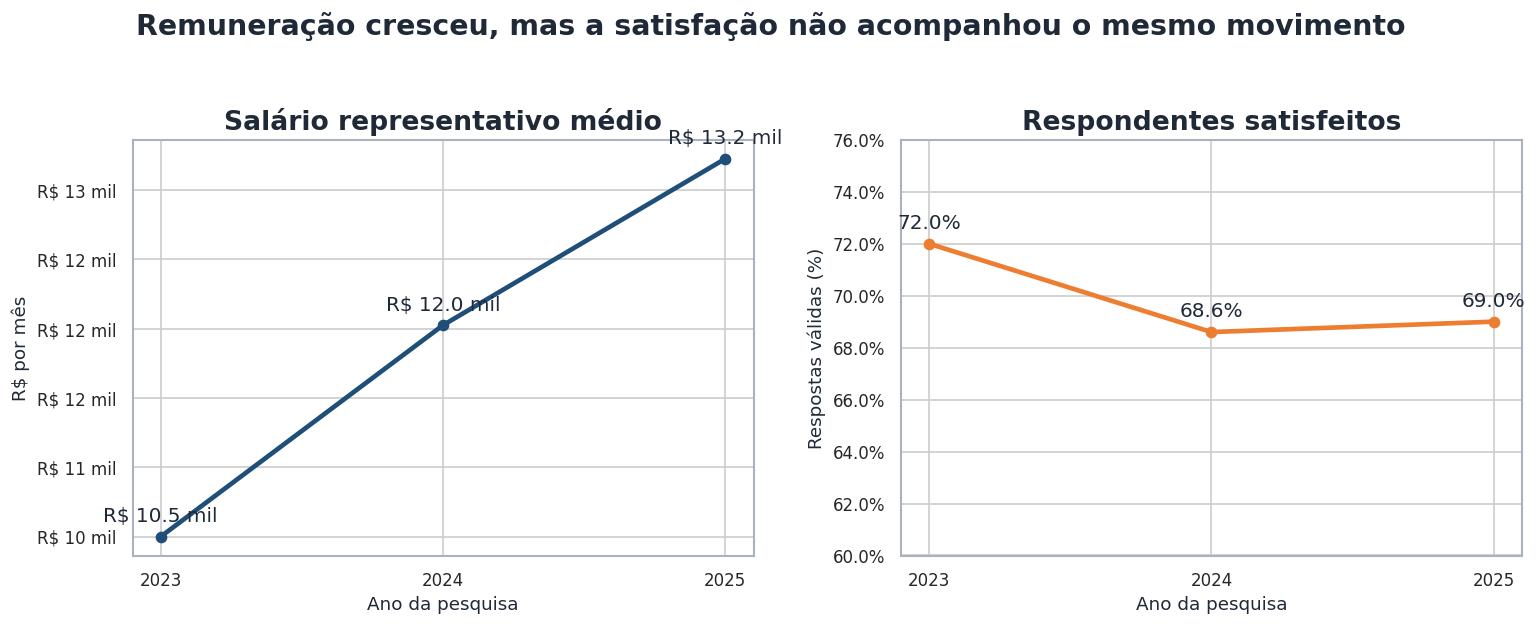

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/01_panorama_salario_satisfacao.png


In [7]:
# Ordena os indicadores para preservar a sequência temporal
panorama = df_indicadores.sort_values("ano_pesquisa").copy()

# Constrói dois painéis com escalas independentes e unidades explícitas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Exibe a evolução do salário representativo médio
axes[0].plot(
    panorama["ano_pesquisa"],
    panorama["salario_representativo_medio"],
    color=CORES["azul"], marker="o", linewidth=2.8
)
axes[0].set_title("Salário representativo médio")
axes[0].set_xlabel("Ano da pesquisa")
axes[0].set_ylabel("R$ por mês")
axes[0].set_xticks([2023, 2024, 2025])
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil")
)
for _, linha in panorama.iterrows():
    axes[0].annotate(
        f"R$ {linha['salario_representativo_medio']/1000:.1f} mil",
        (linha["ano_pesquisa"], linha["salario_representativo_medio"]),
        xytext=(0, 9), textcoords="offset points", ha="center"
    )

# Exibe a evolução do percentual de satisfeitos
axes[1].plot(
    panorama["ano_pesquisa"],
    panorama["pct_satisfeitos"],
    color=CORES["laranja"], marker="o", linewidth=2.8
)
axes[1].set_title("Respondentes satisfeitos")
axes[1].set_xlabel("Ano da pesquisa")
axes[1].set_ylabel("Respostas válidas (%)")
axes[1].set_xticks([2023, 2024, 2025])
axes[1].set_ylim(60, 76)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for _, linha in panorama.iterrows():
    axes[1].annotate(
        f"{linha['pct_satisfeitos']:.1f}%",
        (linha["ano_pesquisa"], linha["pct_satisfeitos"]),
        xytext=(0, 9), textcoords="offset points", ha="center"
    )

fig.suptitle("Remuneração cresceu, mas a satisfação não acompanhou o mesmo movimento", y=1.04, fontsize=17, fontweight="bold")
salvar_grafico("01_panorama_salario_satisfacao.png")

## 7. Evolução das competências técnicas

Os percentuais consideram somente respostas válidas para cada tecnologia. SQL continua amplamente utilizado, enquanto Python e AWS apresentaram as maiores expansões.

,ano_pesquisa,tecnologia,adocao_pct,respostas_validas
0,2023,SQL,83.7,3772
1,2023,Python,74.9,3772
2,2023,AWS,30.6,3613
3,2023,Power BI,57.1,3772
4,2024,SQL,87.7,3587
5,2024,Python,81.8,3587
6,2024,AWS,44.1,3587
7,2024,Power BI,55.2,3617
8,2025,SQL,84.2,2095
9,2025,Python,92.0,2095


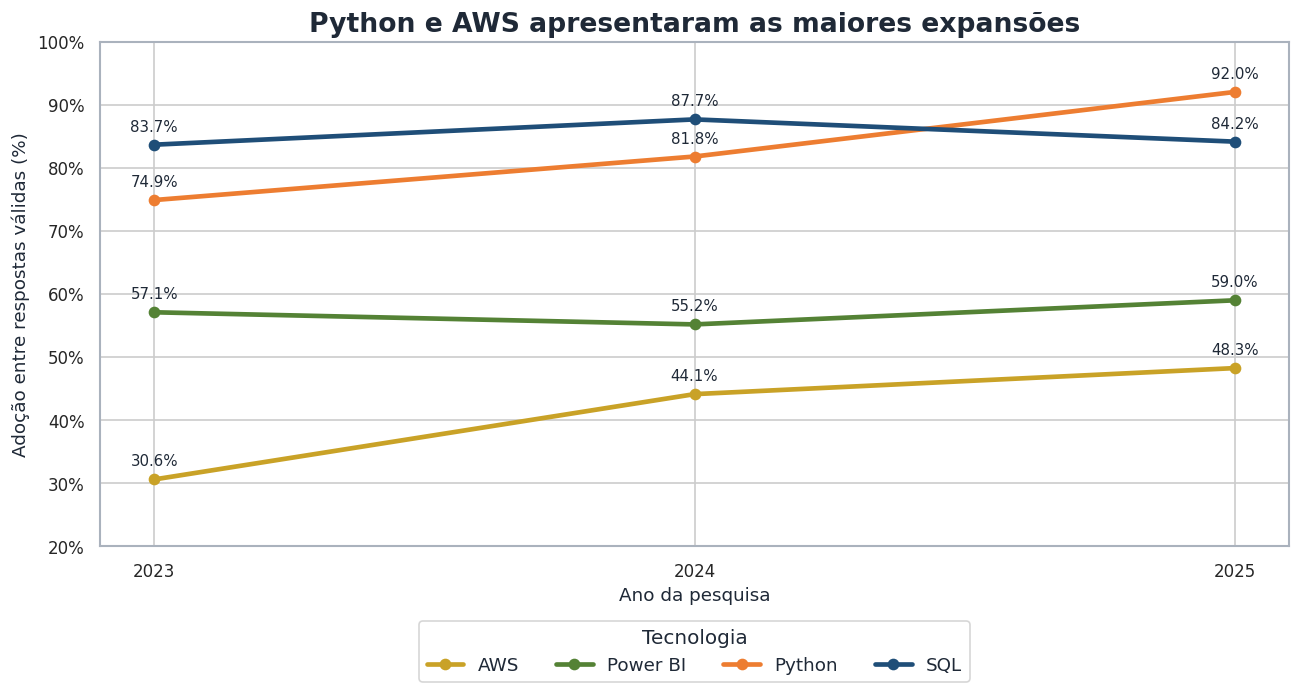

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/02_evolucao_tecnologias.png


In [8]:
# Calcula adoção e denominador válido para cada tecnologia e ano
tecnologias = ["usa_sql", "usa_python", "usa_aws", "usa_power_bi"]
rotulos_tecnologia = {
    "usa_sql": "SQL",
    "usa_python": "Python",
    "usa_aws": "AWS",
    "usa_power_bi": "Power BI",
}

adocao_tecnologias = []
for ano, grupo in df_tecnologias.groupby("ano_pesquisa"):
    for coluna in tecnologias:
        adocao_tecnologias.append({
            "ano_pesquisa": int(ano),
            "tecnologia": rotulos_tecnologia[coluna],
            "adocao_pct": 100 * grupo[coluna].mean(),
            "respostas_validas": int(grupo[coluna].notna().sum()),
        })

adocao_tecnologias = pd.DataFrame(adocao_tecnologias)

# Exibe a tabela que sustenta o gráfico
display(adocao_tecnologias.round({"adocao_pct": 1}))

# Desenha uma linha para cada tecnologia com cores estáveis
cores_tecnologia = {
    "SQL": CORES["azul"],
    "Python": CORES["laranja"],
    "AWS": CORES["dourado"],
    "Power BI": CORES["verde"],
}

fig, ax = plt.subplots(figsize=(11, 6))
for tecnologia, grupo in adocao_tecnologias.groupby("tecnologia"):
    grupo = grupo.sort_values("ano_pesquisa")
    ax.plot(
        grupo["ano_pesquisa"], grupo["adocao_pct"],
        label=tecnologia, color=cores_tecnologia[tecnologia],
        marker="o", linewidth=2.8
    )
    for _, linha in grupo.iterrows():
        ax.annotate(
            f"{linha['adocao_pct']:.1f}%",
            (linha["ano_pesquisa"], linha["adocao_pct"]),
            xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9
        )

ax.set_title("Python e AWS apresentaram as maiores expansões")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Adoção entre respostas válidas (%)")
ax.set_xticks([2023, 2024, 2025])
ax.set_ylim(20, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Tecnologia", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
salvar_grafico("02_evolucao_tecnologias.png")

## 8. Adoção de IA para produtividade

A variável comparável está disponível apenas em 2024 e 2025. Os percentuais usam como denominador quem respondeu à pergunta, portanto não representam toda a amostra anual.

,ano_pesquisa,adocao_pct,respostas_validas
1,2024,93.5,3617
2,2025,97.9,2105


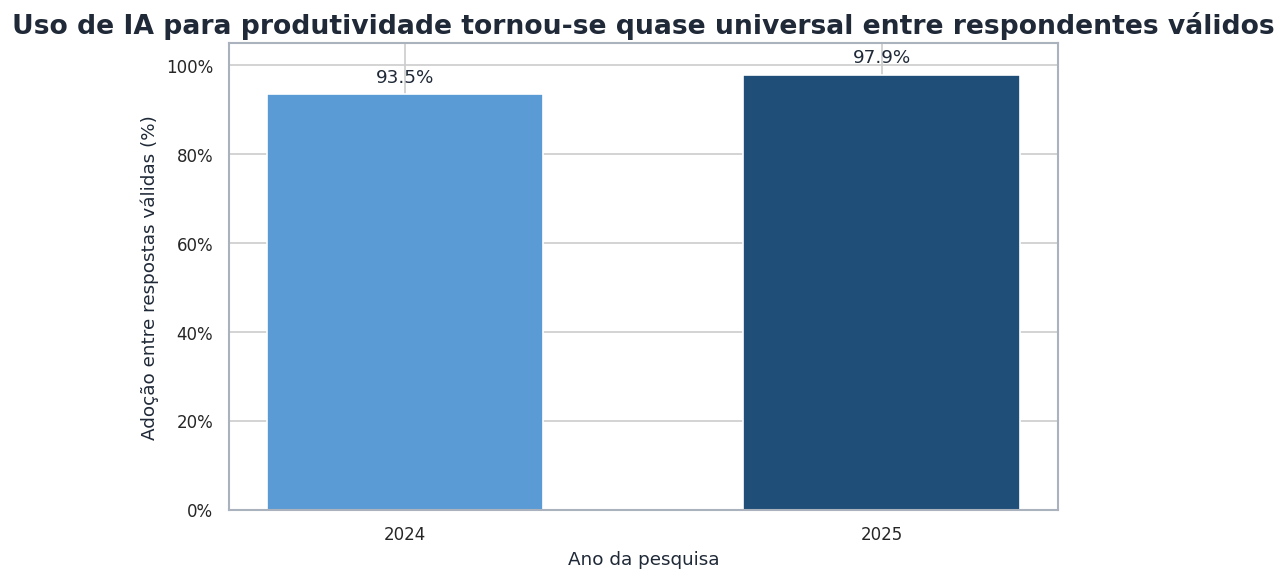

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/03_adocao_ia_produtividade.png


In [9]:
# Calcula adoção de IA e quantidade de respostas válidas por ano
adocao_ia = (
    df_ia.groupby("ano_pesquisa")
    .agg(
        adocao_pct=("usa_ia_produtividade", lambda serie: 100 * serie.mean()),
        respostas_validas=("usa_ia_produtividade", "count"),
    )
    .reset_index()
    .dropna(subset=["adocao_pct"])
    .sort_values("ano_pesquisa")
)

# Exibe os denominadores para evitar interpretação indevida
display(adocao_ia.round({"adocao_pct": 1}))

# Compara os dois anos disponíveis
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(
    adocao_ia["ano_pesquisa"].astype(str),
    adocao_ia["adocao_pct"],
    color=[CORES["azul_claro"], CORES["azul"]], width=0.58
)
ax.bar_label(barras, labels=[f"{v:.1f}%" for v in adocao_ia["adocao_pct"]], padding=5, fontsize=11)
ax.set_title("Uso de IA para produtividade tornou-se quase universal entre respondentes válidos")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Adoção entre respostas válidas (%)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_grafico("03_adocao_ia_produtividade.png")

## 9. Remuneração por senioridade

A análise utiliza o salário representativo das faixas. A categoria Especialista/Staff aparece de maneira comparável apenas na edição de 2025 e, por isso, deve ser interpretada separadamente.

,ano_pesquisa,senioridade,salario_medio,profissionais
0,2023,Júnior,3911.48,1045
3,2024,Júnior,4157.26,868
7,2025,Júnior,4152.51,518
1,2023,Pleno,7539.15,1392
4,2024,Pleno,8049.42,1376
8,2025,Pleno,8298.71,775
2,2023,Sênior,13668.78,1419
5,2024,Sênior,14590.97,1572
9,2025,Sênior,14469.70,858
6,2025,Especialista/Staff+,20028.65,349


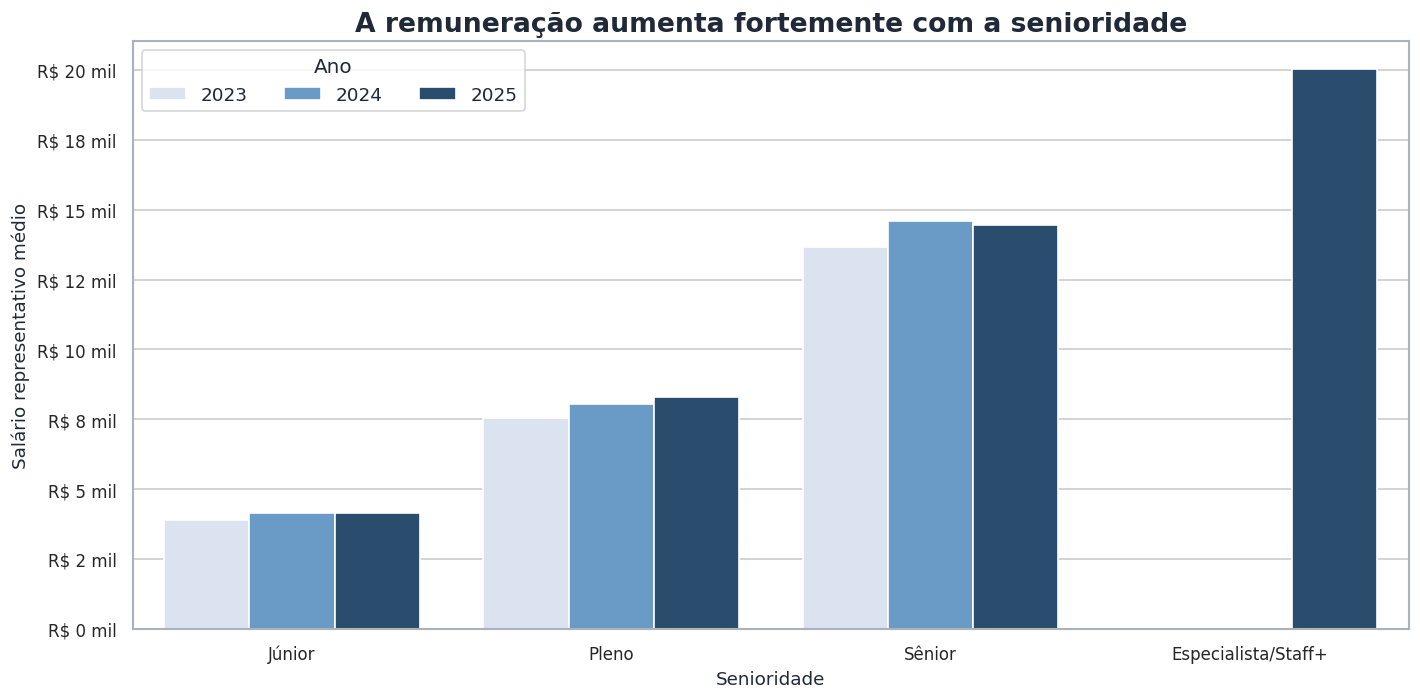

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/04_remuneracao_senioridade.png


In [10]:
# Mantém níveis de senioridade úteis para comparação
ordem_senioridade = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
remuneracao_senioridade = (
    df_remuneracao[
        df_remuneracao["senioridade"].isin(ordem_senioridade)
        & df_remuneracao["salario_representativo"].notna()
    ]
    .groupby(["ano_pesquisa", "senioridade"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Organiza a senioridade como categoria ordenada
remuneracao_senioridade["senioridade"] = pd.Categorical(
    remuneracao_senioridade["senioridade"],
    categories=ordem_senioridade,
    ordered=True,
)

# Exibe a tabela com médias e tamanhos de amostra
display(remuneracao_senioridade.sort_values(["senioridade", "ano_pesquisa"]).round(2))

# Desenha barras agrupadas por ano
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=remuneracao_senioridade,
    x="senioridade", y="salario_medio", hue="ano_pesquisa",
    palette=[CORES["cinza_claro"], CORES["azul_claro"], CORES["azul"]], ax=ax
)
ax.set_title("A remuneração aumenta fortemente com a senioridade")
ax.set_xlabel("Senioridade")
ax.set_ylabel("Salário representativo médio")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
ax.legend(title="Ano", ncol=3, loc="upper left")
salvar_grafico("04_remuneracao_senioridade.png")

## 10. Modelo de trabalho

Para comparar a composição, o gráfico exclui “Não informado” e recalcula os percentuais sobre respostas válidas. A mudança mais recente aproxima a participação do remoto e do híbrido.

modelo_trabalho_resumo,Remoto,Híbrido,Presencial
ano_pesquisa,,,
2023,46.3,37.1,16.6
2024,45.7,38.0,16.3
2025,39.7,39.5,20.8


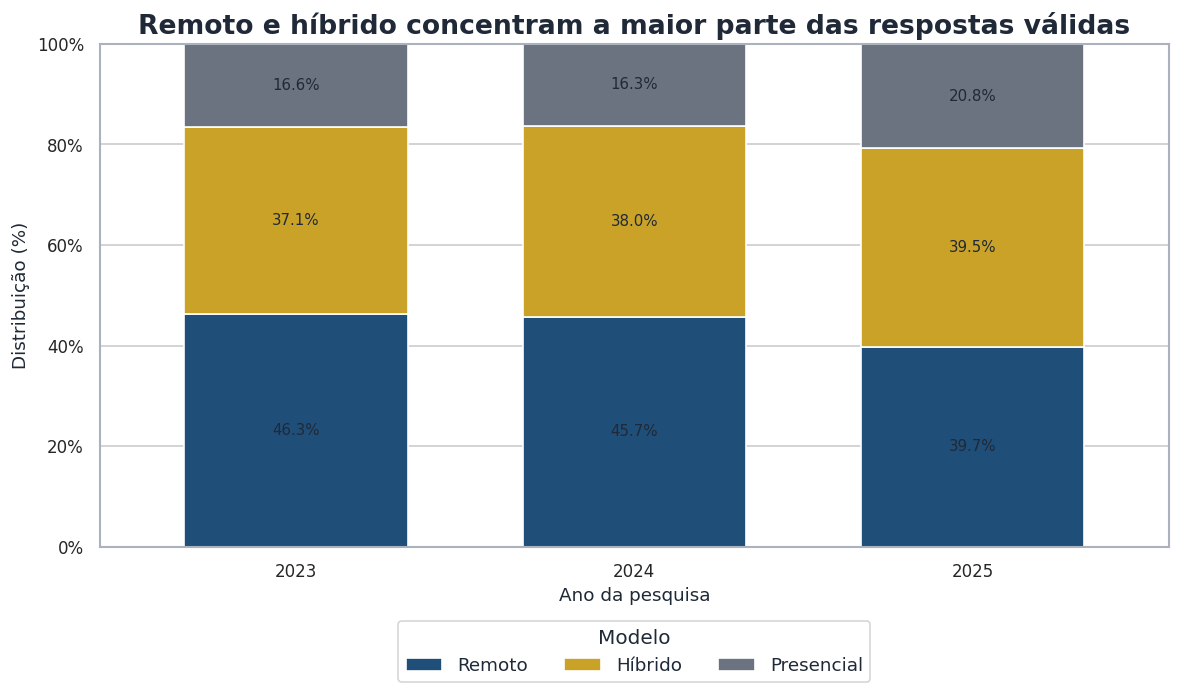

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/05_composicao_modelo_trabalho.png


In [11]:
# Mantém apenas os três modelos comparáveis
modelos_validos = ["Remoto", "Híbrido", "Presencial"]
trabalho_valido = df_modelo_trabalho[
    df_modelo_trabalho["modelo_trabalho_resumo"].isin(modelos_validos)
].copy()

# Calcula a participação dentro das respostas válidas de cada ano
composicao_trabalho = (
    trabalho_valido.groupby(["ano_pesquisa", "modelo_trabalho_resumo"])
    .size()
    .rename("profissionais")
    .reset_index()
)
composicao_trabalho["percentual"] = (
    100 * composicao_trabalho["profissionais"]
    / composicao_trabalho.groupby("ano_pesquisa")["profissionais"].transform("sum")
)

# Transforma os dados para um gráfico empilhado de composição
trabalho_pivot = (
    composicao_trabalho.pivot(
        index="ano_pesquisa", columns="modelo_trabalho_resumo", values="percentual"
    )
    .reindex(columns=modelos_validos)
    .sort_index()
)

# Exibe os percentuais usados no gráfico
display(trabalho_pivot.round(1))

# Cria barras 100% empilhadas
fig, ax = plt.subplots(figsize=(10, 6))
trabalho_pivot.plot(
    kind="bar", stacked=True, ax=ax,
    color=[CORES["azul"], CORES["dourado"], CORES["cinza"]], width=0.66
)
ax.set_title("Remoto e híbrido concentram a maior parte das respostas válidas")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Distribuição (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Modelo", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.13))

# Inclui rótulos nas parcelas com espaço suficiente
acumulado = np.zeros(len(trabalho_pivot))
for coluna in trabalho_pivot.columns:
    valores = trabalho_pivot[coluna].values
    for indice, valor in enumerate(valores):
        ax.text(indice, acumulado[indice] + valor / 2, f"{valor:.1f}%", ha="center", va="center", fontsize=9)
    acumulado += valores

salvar_grafico("05_composicao_modelo_trabalho.png")

## 11. Satisfação, remuneração e modelo de trabalho

Respondentes satisfeitos apresentam salário representativo médio maior em todos os anos. Ao mesmo tempo, o remoto registra satisfação superior ao presencial. Os dados indicam associações simultâneas e não permitem atribuir a satisfação exclusivamente ao salário.

,ano_pesquisa,satisfeito,salario_medio,profissionais,grupo_satisfacao
0,2023,0.0,8000.38,1333,Insatisfeitos
1,2023,1.0,11474.26,3419,Satisfeitos
2,2024,0.0,9713.16,1527,Insatisfeitos
3,2024,1.0,13083.68,3334,Satisfeitos
4,2025,0.0,10484.52,1001,Insatisfeitos
5,2025,1.0,14458.45,2226,Satisfeitos


,ano_pesquisa,modelo_trabalho_resumo,satisfacao_pct,profissionais
0,2023,Híbrido,71.9,1762
1,2023,Presencial,54.7,790
2,2023,Remoto,78.2,2201
3,2024,Híbrido,68.9,1848
4,2024,Presencial,49.7,792
5,2024,Remoto,75.0,2221
6,2025,Híbrido,71.3,1276
7,2025,Presencial,54.0,670
8,2025,Remoto,74.5,1281


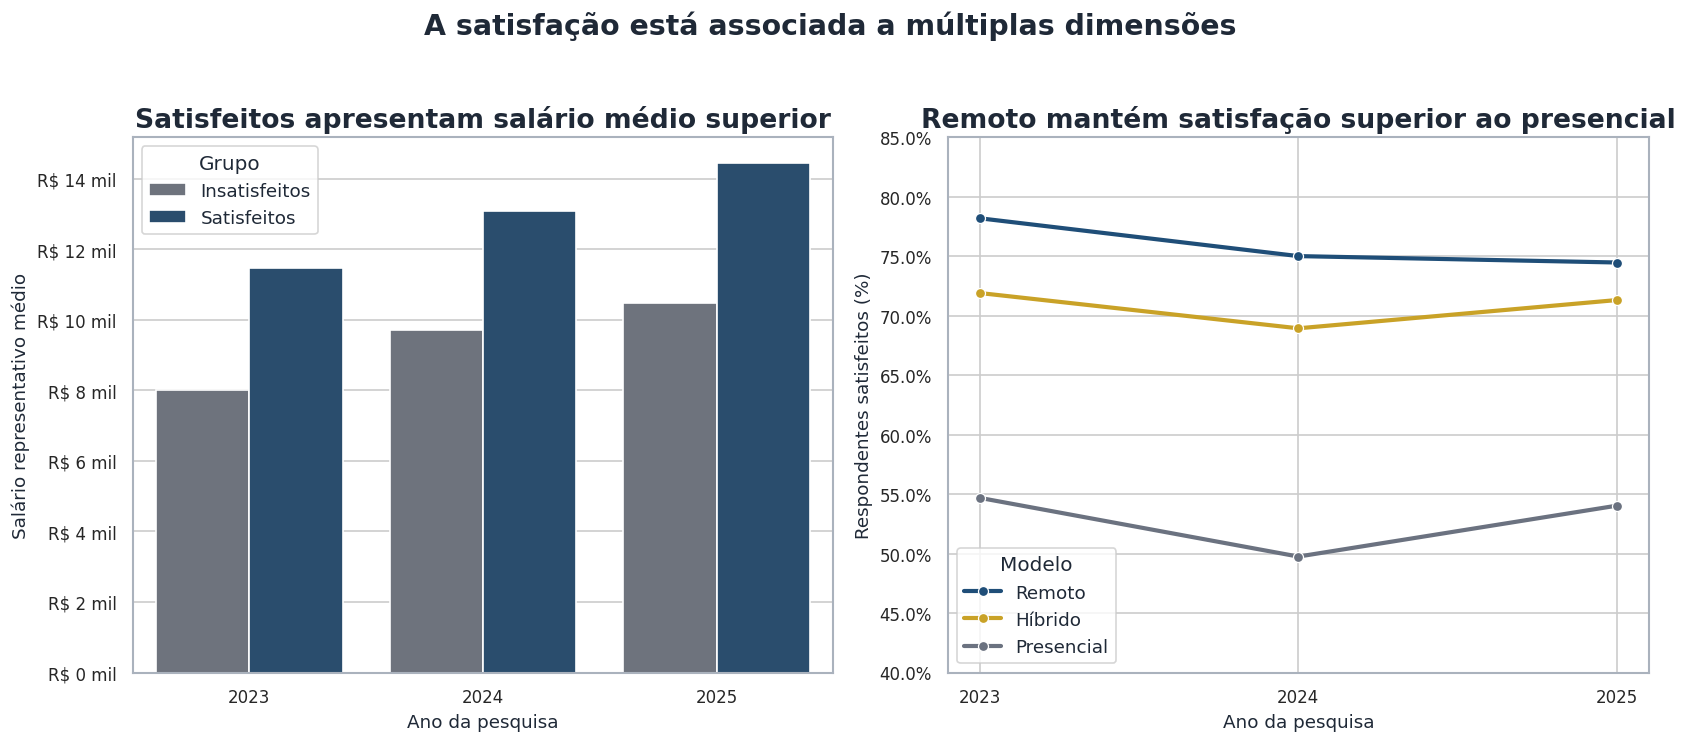

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/06_satisfacao_salario_modelo.png


In [12]:
# Compara o salário médio entre respondentes satisfeitos e insatisfeitos
satisfacao_salario = (
    df_satisfacao.dropna(subset=["satisfeito", "salario_representativo"])
    .groupby(["ano_pesquisa", "satisfeito"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)
satisfacao_salario["grupo_satisfacao"] = satisfacao_salario["satisfeito"].map({0: "Insatisfeitos", 1: "Satisfeitos"})

# Calcula satisfação por modelo de trabalho e ano
satisfacao_modelo = (
    df_satisfacao[
        df_satisfacao["satisfeito"].notna()
        & df_satisfacao["modelo_trabalho_resumo"].isin(modelos_validos)
    ]
    .groupby(["ano_pesquisa", "modelo_trabalho_resumo"])
    .agg(
        satisfacao_pct=("satisfeito", lambda serie: 100 * serie.mean()),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Exibe as duas tabelas analíticas
display(satisfacao_salario.round(2))
display(satisfacao_modelo.round(1))

# Cria dois painéis complementares
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Painel 1: salário médio por satisfação
sns.barplot(
    data=satisfacao_salario,
    x="ano_pesquisa", y="salario_medio", hue="grupo_satisfacao",
    palette=[CORES["cinza"], CORES["azul"]], ax=axes[0]
)
axes[0].set_title("Satisfeitos apresentam salário médio superior")
axes[0].set_xlabel("Ano da pesquisa")
axes[0].set_ylabel("Salário representativo médio")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
axes[0].legend(title="Grupo")

# Painel 2: satisfação por modelo de trabalho
sns.lineplot(
    data=satisfacao_modelo,
    x="ano_pesquisa", y="satisfacao_pct", hue="modelo_trabalho_resumo",
    hue_order=modelos_validos,
    palette=[CORES["azul"], CORES["dourado"], CORES["cinza"]],
    marker="o", linewidth=2.5, ax=axes[1]
)
axes[1].set_title("Remoto mantém satisfação superior ao presencial")
axes[1].set_xlabel("Ano da pesquisa")
axes[1].set_ylabel("Respondentes satisfeitos (%)")
axes[1].set_xticks([2023, 2024, 2025])
axes[1].set_ylim(40, 85)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title="Modelo")

fig.suptitle("A satisfação está associada a múltiplas dimensões", y=1.03, fontsize=17, fontweight="bold")
salvar_grafico("06_satisfacao_salario_modelo.png")

## 12. Diversidade e remuneração controlada por senioridade

A diferença agregada entre homens e mulheres pode refletir composição de cargos, senioridade, experiência e região. O recorte abaixo compara as médias dentro dos mesmos níveis, reduzindo parte desse efeito de composição sem constituir uma análise causal completa.

genero,ano_pesquisa,senioridade,Feminino,Masculino,diferenca_feminino_vs_masculino_pct
0,2023,Júnior,3693.98,3994.61,-7.53
1,2023,Pleno,7462.91,7572.11,-1.44
2,2023,Sênior,12420.20,13957.50,-11.01
3,2024,Júnior,4148.76,4101.93,1.14
4,2024,Pleno,7824.66,8133.20,-3.79
5,2024,Sênior,12543.28,15155.94,-17.24
6,2025,Júnior,3780.82,4322.89,-12.54
7,2025,Pleno,8335.26,8296.33,0.47
8,2025,Sênior,12165.73,15077.78,-19.31


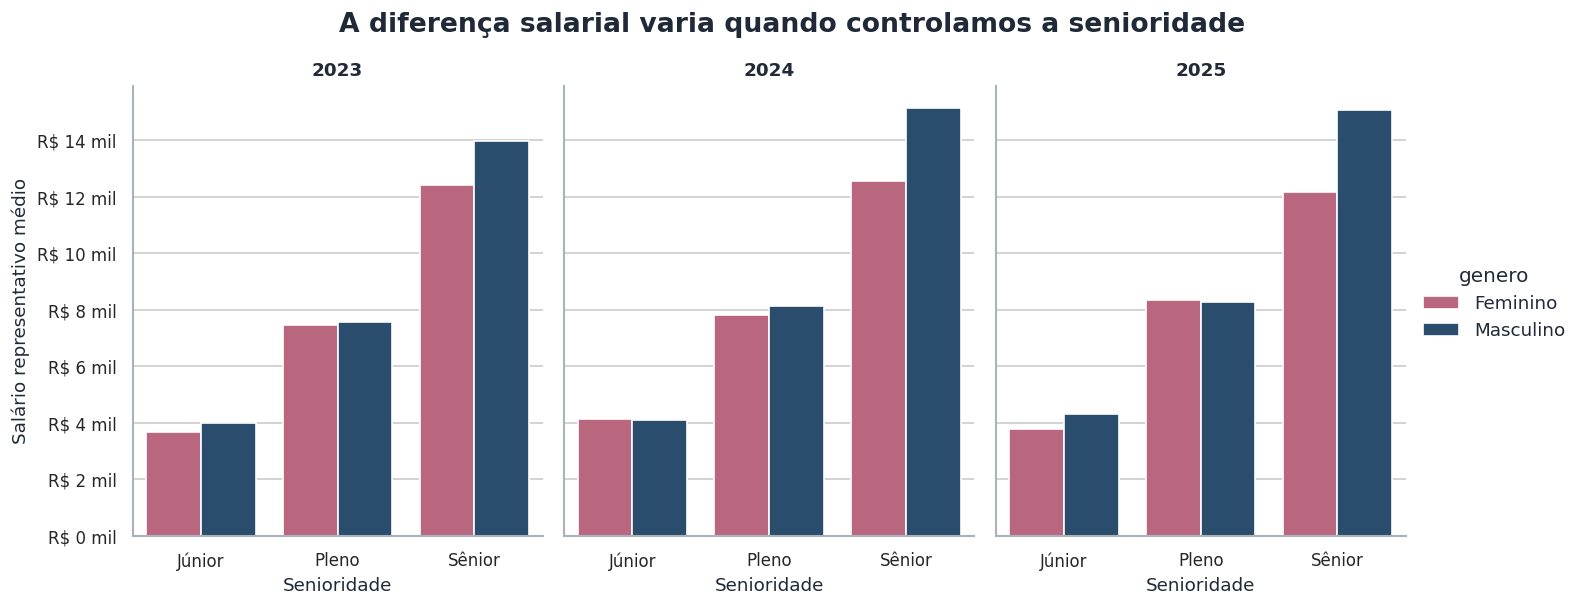

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/07_remuneracao_genero_senioridade.png


In [13]:
# Mantém os dois grupos com amostras suficientes e senioridades comparáveis
niveis_comparaveis = ["Júnior", "Pleno", "Sênior"]
genero_senioridade = df_remuneracao[
    df_remuneracao["genero"].isin(["Feminino", "Masculino"])
    & df_remuneracao["senioridade"].isin(niveis_comparaveis)
    & df_remuneracao["salario_representativo"].notna()
].copy()

# Calcula salário médio e tamanho da amostra por grupo
remuneracao_genero = (
    genero_senioridade.groupby(["ano_pesquisa", "senioridade", "genero"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Calcula a diferença percentual feminina em relação à média masculina dentro do mesmo nível
comparacao_genero = (
    remuneracao_genero.pivot_table(
        index=["ano_pesquisa", "senioridade"], columns="genero", values="salario_medio"
    )
    .reset_index()
)
comparacao_genero["diferenca_feminino_vs_masculino_pct"] = (
    100 * (comparacao_genero["Feminino"] / comparacao_genero["Masculino"] - 1)
)

# Exibe o recorte ajustado por senioridade
display(comparacao_genero.round(2))

# Ordena os níveis no gráfico
remuneracao_genero["senioridade"] = pd.Categorical(
    remuneracao_genero["senioridade"], categories=niveis_comparaveis, ordered=True
)

# Cria pequenos múltiplos, um para cada ano
grafico_genero = sns.catplot(
    data=remuneracao_genero,
    x="senioridade", y="salario_medio", hue="genero", col="ano_pesquisa",
    kind="bar", height=4.8, aspect=0.82,
    palette={"Feminino": CORES["rosa"], "Masculino": CORES["azul"]}
)
grafico_genero.set_axis_labels("Senioridade", "Salário representativo médio")
grafico_genero.set_titles("{col_name}")
grafico_genero.figure.suptitle("A diferença salarial varia quando controlamos a senioridade", y=1.05, fontsize=16, fontweight="bold")
for eixo in grafico_genero.axes.flat:
    eixo.yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
    eixo.tick_params(axis="x", rotation=0)

plt.savefig(OUTPUT_DIR / "07_remuneracao_genero_senioridade.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Gráfico salvo em:", OUTPUT_DIR / "07_remuneracao_genero_senioridade.png")

## 13. Principais cargos

Como os volumes anuais são diferentes, utilizamos participação percentual entre respondentes com cargo informado, e não apenas contagens absolutas.

,ano_pesquisa,cargo_resumido,profissionais,participacao_pct
1,2023,Analista de Dados,907,23.5
6,2023,Cientista de Dados,687,17.8
11,2023,Engenharia/Arquitetura de Dados,684,17.7
0,2023,Analista de BI,506,13.1
14,2023,Outros cargos,262,6.8
18,2024,Analista de Dados,957,25.1
23,2024,Cientista de Dados,687,18.0
26,2024,Engenharia/Arquitetura de Dados,612,16.0
17,2024,Analista de BI,396,10.4
29,2024,Outros cargos,254,6.7


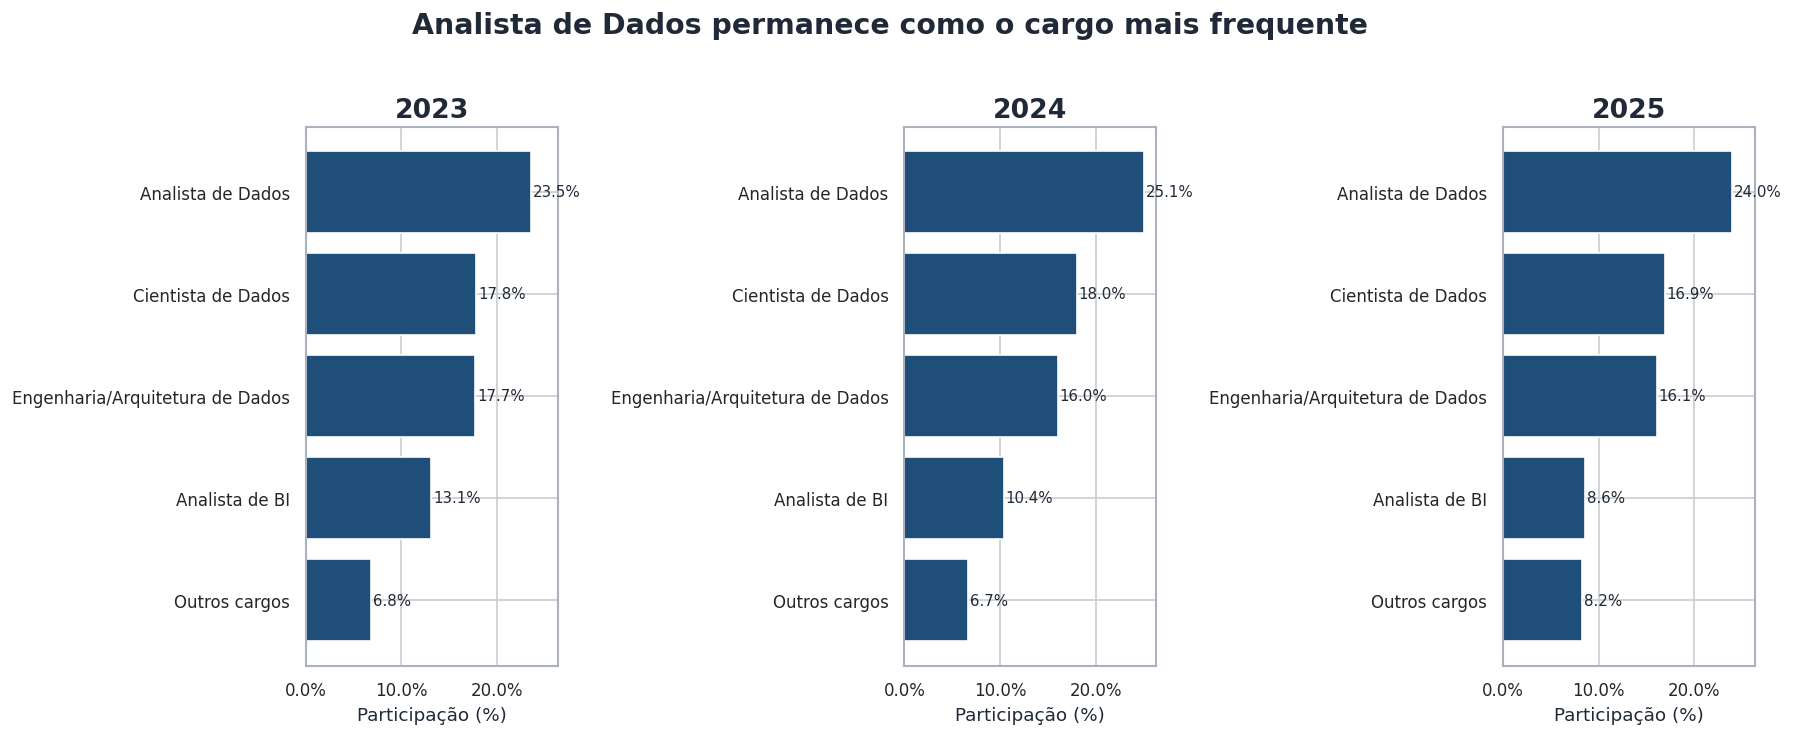

Gráfico salvo em: /content/drive/MyDrive/Tech_Challenge_Fase_3/outputs/graficos_gold/08_top_cargos.png


In [14]:
# Calcula a participação de cada cargo dentro dos cargos informados em cada ano
cargos = (
    df_mercado.dropna(subset=["cargo"])
    .groupby(["ano_pesquisa", "cargo"])
    .size()
    .rename("profissionais")
    .reset_index()
)
cargos["participacao_pct"] = (
    100 * cargos["profissionais"]
    / cargos.groupby("ano_pesquisa")["profissionais"].transform("sum")
)

# Seleciona os cinco cargos mais frequentes de cada ano
top_cargos = (
    cargos.sort_values(["ano_pesquisa", "profissionais"], ascending=[True, False])
    .groupby("ano_pesquisa", group_keys=False)
    .head(5)
)

# Simplifica rótulos longos sem alterar a categoria original nos dados
nomes_cargos = {
    "Analista de Dados/Data Analyst": "Analista de Dados",
    "Cientista de Dados/Data Scientist": "Cientista de Dados",
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect": "Engenharia/Arquitetura de Dados",
    "Engenheiro de Dados/Data Engineer/Data Architect": "Engenharia/Arquitetura de Dados",
    "Analista de BI/BI Analyst": "Analista de BI",
    "Outra Opção": "Outros cargos",
}
top_cargos["cargo_resumido"] = top_cargos["cargo"].replace(nomes_cargos)

# Exibe as participações exatas antes do gráfico
display(top_cargos[["ano_pesquisa", "cargo_resumido", "profissionais", "participacao_pct"]].round(1))

# Cria um painel por ano com escala comum
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
for eixo, (ano, grupo) in zip(axes, top_cargos.groupby("ano_pesquisa")):
    grupo = grupo.sort_values("participacao_pct", ascending=True)
    eixo.barh(grupo["cargo_resumido"], grupo["participacao_pct"], color=CORES["azul"])
    eixo.set_title(str(ano))
    eixo.set_xlabel("Participação (%)")
    eixo.xaxis.set_major_formatter(mtick.PercentFormatter())
    for indice, valor in enumerate(grupo["participacao_pct"]):
        eixo.text(valor + 0.2, indice, f"{valor:.1f}%", va="center", fontsize=9)

fig.suptitle("Analista de Dados permanece como o cargo mais frequente", y=1.02, fontsize=17, fontweight="bold")
salvar_grafico("08_top_cargos.png")

## 14. Recomendações para uma instituição financeira

### Competências

SQL permanece como base técnica, com 84,2% de adoção entre respostas válidas em 2025. Python alcançou 92,0% e AWS avançou de 30,6% para 48,3% entre 2023 e 2025. A instituição deve preservar SQL e BI nas trilhas de formação e ampliar Python e Cloud conforme a função e a arquitetura adotada.

### IA

Entre quem respondeu à pergunta, o uso de IA para produtividade passou de 93,5% em 2024 para 97,9% em 2025. O banco deve complementar capacitação com governança, segurança, privacidade e critérios de uso, pois a adoção elevada não demonstra maturidade organizacional.

### Carreira e retenção

O salto de remuneração entre Pleno, Sênior e Especialista reforça a importância de uma carreira técnica explícita. Trilhas de especialista ajudam a reter profissionais experientes sem exigir migração para gestão.

### Flexibilidade e satisfação

Respondentes satisfeitos recebem, em média, remuneração superior aos insatisfeitos. Porém, o remoto apresenta satisfação consistentemente maior que o presencial. Políticas de retenção devem combinar remuneração competitiva com flexibilidade e condições de trabalho.

### Diversidade

A diferença salarial agregada entre homens e mulheres permanece relevante, mas varia quando a senioridade é controlada. A recomendação é acompanhar equidade por grupos comparáveis, incluindo cargo, senioridade, experiência e região.

## 15. Arquivos gerados

Os gráficos são salvos automaticamente em `outputs/graficos_gold` no repositório ou em `Tech_Challenge_Fase_3/outputs/graficos_gold` no Google Drive. Eles podem ser utilizados diretamente na apresentação executiva.

In [15]:
# Lista os gráficos exportados para conferência final
graficos_gerados = sorted(OUTPUT_DIR.glob("*.png"))

# Exibe nome e tamanho de cada arquivo
arquivos_saida = pd.DataFrame([
    {
        "arquivo": grafico.name,
        "tamanho_kb": round(grafico.stat().st_size / 1024, 1),
    }
    for grafico in graficos_gerados
])

display(arquivos_saida)
print(f"Total de gráficos gerados: {len(graficos_gerados)}")

,arquivo,tamanho_kb
0,01_panorama_salario_satisfacao.png,179.3
1,02_evolucao_tecnologias.png,155.5
2,03_adocao_ia_produtividade.png,84.1
3,04_remuneracao_senioridade.png,89.5
4,05_composicao_modelo_trabalho.png,95.6
5,06_satisfacao_salario_modelo.png,206.7
6,07_remuneracao_genero_senioridade.png,92.8
7,08_top_cargos.png,119.9


Total de gráficos gerados: 8


## Conclusão

Os dados apontam uma expansão do perfil técnico em direção a Python, Cloud e IA, sem reduzir a relevância de SQL e BI. A atração e retenção de profissionais exigem uma combinação de carreira técnica, remuneração, flexibilidade e acompanhamento de equidade. Essas conclusões descrevem associações observadas na pesquisa e devem ser interpretadas com as limitações amostrais e metodológicas registradas no notebook.